# Pregenerated map gallery and label scores


The application's central map is one choice of inputs. This notebook builds a small gallery of alternatives for each organism -- all measurements at three neighbourhood sizes, all but localization, and one map per evidence family -- and scores how well every categorical label maps onto each. The code is `scripts/build_umap_gallery.py` and `starplast/umap_gallery.py`; this notebook calls them, so what is shown is what ships.

Every map is built from measurements only: label columns are removed from the table before embedding, and the build refuses a map whose matrix contains one.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '/media/carruthers/mnt3/claude/repo/starplast/.claude/worktrees/agent-a1f12183a8e4e55e2'); sys.path.insert(0, '/media/carruthers/mnt3/claude/repo/starplast/.claude/worktrees/agent-a1f12183a8e4e55e2/scripts')
import build_umap_gallery as B
from starplast import umap_gallery as G
import pandas as pd
_ = pd.set_option('display.width', 200)

## 1. The recipes

A family map needs at least 4 source columns and 400 genes measured in at least 50% of them; only those genes are placed. The 'all' maps place every gene, as the application does.

In [2]:
rows = []
for code in ['Tg', 'Pf']:
    ctx = B.context(code)
    for r in G.recipes(ctx):
        rows.append({'organism': code, 'map': r['id'], 'blocks': len(r['blocks']),
                     'columns': len(r['columns']), 'genes': len(G.genes_for(ctx, r)),
                     'n_neighbors': r['n_neighbors']})
recipes = pd.DataFrame(rows)
print(recipes.to_string())

   organism                       map  blocks  columns  genes  n_neighbors
0        Tg                  all_nn10     105      394   8140           10
1        Tg                  all_nn25     105      394   8140           25
2        Tg                  all_nn60     105      394   8140           60
3        Tg      all_but_localization      98      373   8140           25
4        Tg            family_fitness      25       39   7388           25
5        Tg       family_localization       7       21    696           25
6        Tg  family_protein_abundance       4       27   3005           25
7        Tg         family_regulation       6        7   6042           25
8        Tg           family_relation       6        7   7495           25
9        Tg           family_sequence       8       29   6057           25
10       Tg      family_transcription      22      166   7875           25
11       Tg        family_translation       8       49   7880           25
12       Pf              

## 2. Build every map

3D UMAP (umap-learn on the CPU, seed 42, min_dist 0.25, robust scaling, median imputation, each block scaled to equal total variance), then HDBSCAN with {'min_cluster_size': 25, 'min_samples': 5, 'cluster_selection_method': 'leaf'}.

Why not the Clusters tab's opening setting (25/25, 'eom'): on these maps it returns one to a few clusters holding almost every gene, so every label scores at chance. The next cell measures both on the shipped maps before the gallery is written.

In [3]:
built = B.build(['Tg', 'Pf'], workers=8)
maps = B.maps_table(built)
print(maps.to_string())

26 maps over Tg, Pf on 8 worker(s)
  Tg all_nn10: 8,140 genes, 314 features, 75 clusters, 51% unclustered (64.4 s)
  Tg all_nn25: 8,140 genes, 314 features, 66 clusters, 58% unclustered (67.6 s)
  Tg all_nn60: 8,140 genes, 314 features, 61 clusters, 60% unclustered (74.8 s)
  Tg all_but_localization: 8,140 genes, 300 features, 62 clusters, 53% unclustered (71.5 s)
  Tg family_fitness: 7,388 genes, 39 features, 58 clusters, 56% unclustered (41.9 s)
  Tg family_localization: 696 genes, 14 features, 12 clusters, 12% unclustered (13.6 s)
  Tg family_protein_abundance: 3,005 genes, 12 features, 35 clusters, 38% unclustered (20.1 s)
  Tg family_regulation: 6,042 genes, 7 features, 64 clusters, 49% unclustered (26.4 s)
  Tg family_relation: 7,495 genes, 7 features, 147 clusters, 14% unclustered (67.6 s)
  Tg family_sequence: 6,057 genes, 20 features, 70 clusters, 40% unclustered (50.5 s)
  Tg family_transcription: 7,875 genes, 122 features, 56 clusters, 57% unclustered (38.7 s)
  Tg family_tr

In [4]:
compare = B.compare_clusterings(built)
print(compare.to_string())
print(compare.groupby(['organism', 'setting'])[['clusters', 'unclustered', 'category_skill']].median())

   organism              label                       map                setting  clusters  unclustered  category_f1  category_skill
0        Tg        compartment                  all_nn10  tab opening 25/25 eom         9        0.022        0.184           0.010
1        Tg        compartment                  all_nn10                gallery        75        0.509        0.131           0.084
2        Tg        compartment                  all_nn25  tab opening 25/25 eom         6        0.013        0.185           0.010
3        Tg        compartment                  all_nn25                gallery        66        0.576        0.138           0.091
4        Tg        compartment                  all_nn60  tab opening 25/25 eom         5        0.026        0.183           0.009
5        Tg        compartment                  all_nn60                gallery        61        0.604        0.140           0.090
6        Tg        compartment      all_but_localization  tab opening 25/25 

### The Tg maps, first two components, colored by cluster

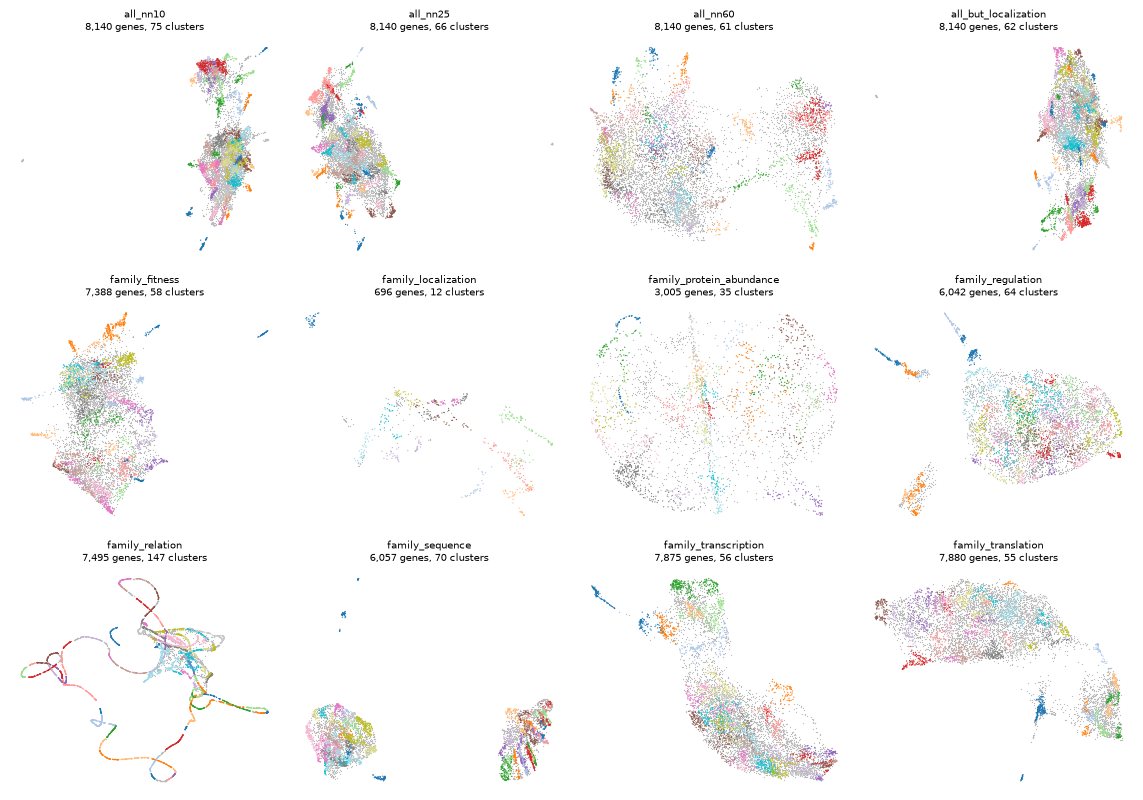

In [5]:
B.figure(built, 'Tg')

### The Pf maps, first two components, colored by cluster

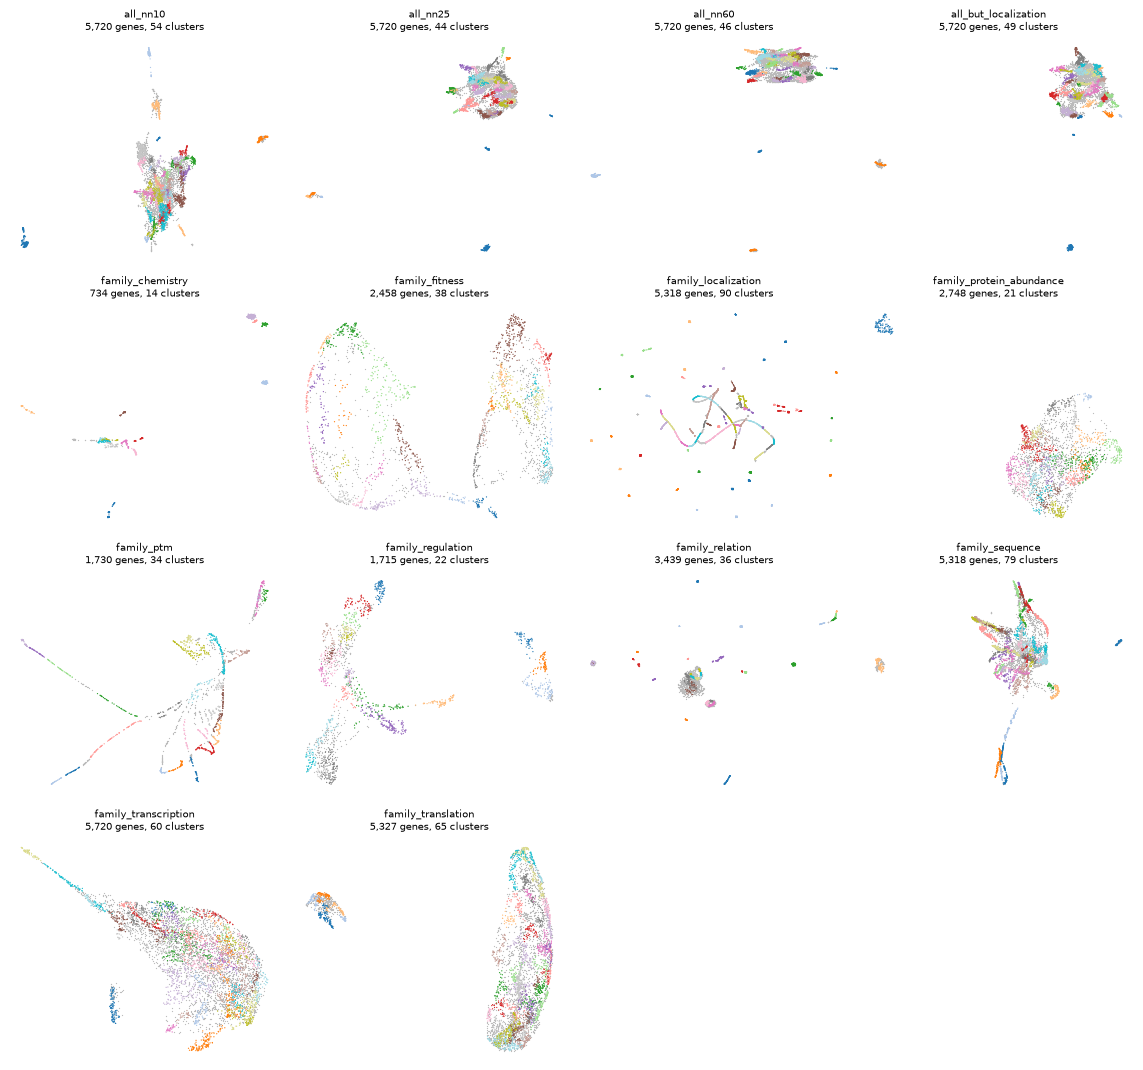

In [6]:
B.figure(built, 'Pf')

## 3. Score every label on every map

Categories → clusters: size-weighted mean over categories of the F1 of each category's best cluster (unclustered genes count as missed). Best category: the category whose F1 of the Wilson 95% lower bounds of precision and recall beats its own shuffled-label chance by the most. Chance: 5 shuffles of the label over the same genes. Circular: the map was built from a column in the label's leakage closure.

In [7]:
scores = B.score(built)
print(len(scores), 'label x map rows')
scores.groupby('organism').size()

scoring Tg all_nn10
scoring Tg all_nn25
scoring Tg all_nn60
scoring Tg all_but_localization
scoring Tg family_fitness
scoring Tg family_localization
scoring Tg family_protein_abundance
scoring Tg family_regulation
scoring Tg family_relation
scoring Tg family_sequence
scoring Tg family_transcription
scoring Tg family_translation
scoring Pf all_nn10
scoring Pf all_nn25
scoring Pf all_nn60
scoring Pf all_but_localization
scoring Pf family_chemistry
scoring Pf family_fitness
scoring Pf family_localization
scoring Pf family_protein_abundance
scoring Pf family_ptm
scoring Pf family_regulation
scoring Pf family_relation
scoring Pf family_sequence
scoring Pf family_transcription
scoring Pf family_translation
468 label x map rows


organism
Pf    252
Tg    216

### Tg: its first calibration target on every map

Best first by 'categories → clusters' skill. A map marked circular was built from a column that restates the label.

In [8]:
label = B.headline_label('Tg')
print(label)
print(G.describe(scores[scores.organism == 'Tg'], label))

compartment
family_localization      categories→clusters 0.403 (skill +0.305)  best dense granules n=41 0.599 (skill +0.567)  [circular]
all_nn25                 categories→clusters 0.138 (skill +0.092)  best 60S ribosome n=40 0.543 (skill +0.533)  [circular]
all_nn60                 categories→clusters 0.140 (skill +0.091)  best 60S ribosome n=40 0.524 (skill +0.513)  [circular]
all_nn10                 categories→clusters 0.131 (skill +0.084)  best PM - peripheral 1 n=49 0.434 (skill +0.423)  [circular]
all_but_localization     categories→clusters 0.123 (skill +0.071)  best 60S ribosome n=40 0.423 (skill +0.410)
family_transcription     categories→clusters 0.103 (skill +0.053)  best 60S ribosome n=40 0.373 (skill +0.364)
family_fitness           categories→clusters 0.103 (skill +0.046)  best dense granules n=180 0.326 (skill +0.307)
family_sequence          categories→clusters 0.095 (skill +0.046)  best PM - peripheral 1 n=33 0.479 (skill +0.470)
family_translation       categories→c

### Pf: its first calibration target on every map

Best first by 'categories → clusters' skill. A map marked circular was built from a column that restates the label.

In [9]:
label = B.headline_label('Pf')
print(label)
print(G.describe(scores[scores.organism == 'Pf'], label))

lopit_pf_location
family_protein_abundance categories→clusters 0.215 (skill +0.128)  best ribosomes n=64 0.525 (skill +0.500)  [circular]
family_localization      categories→clusters 0.194 (skill +0.117)  best erythrocyte membrane n=42 0.347 (skill +0.325)  [circular]
all_nn10                 categories→clusters 0.181 (skill +0.112)  best ribosomes n=65 0.599 (skill +0.581)  [circular]
all_nn60                 categories→clusters 0.166 (skill +0.099)  best ribosomes n=65 0.569 (skill +0.557)  [circular]
all_but_localization     categories→clusters 0.171 (skill +0.097)  best ribosomes n=65 0.610 (skill +0.597)  [circular]
all_nn25                 categories→clusters 0.169 (skill +0.088)  best ribosomes n=65 0.615 (skill +0.602)  [circular]
family_fitness           categories→clusters 0.145 (skill +0.042)  best ribosomes n=31 0.122 (skill +0.085)
family_transcription     categories→clusters 0.118 (skill +0.041)  best ribosomes n=65 0.566 (skill +0.556)
family_regulation        categories

## 4. The size-aware bound on real data

Across every label and map: how often the best category by raw F1 is a small category, and how often it still is once the Wilson bound and the chance correction decide.

In [10]:
small = scores[scores.best_n < 30]
print(f'best categories under 30 genes: {len(small)} of {len(scores)}')
print(small[['organism', 'label', 'map', 'best_category', 'best_n', 'best_precision', 'best_recall', 'best_f1_lower', 'best_skill']].round(3).head(15).to_string())

best categories under 30 genes: 63 of 468
    organism                         label                   map     best_category  best_n  best_precision  best_recall  best_f1_lower  best_skill
8         Tg            compartment_source              all_nn10        orthoLOPIT      28           0.057        0.071          0.018       0.002
15        Tg          screen_scorers_agree              all_nn10              True      27           0.750        0.111          0.068       0.033
26        Tg            compartment_source              all_nn25        orthoLOPIT      28           0.120        0.107          0.039       0.025
33        Tg          screen_scorers_agree              all_nn25              True      27           0.667        0.074          0.037       0.000
51        Tg          screen_scorers_agree              all_nn60              True      27           0.667        0.074          0.037       0.010
62        Tg            compartment_source  all_but_localization        orth

## 5. Write the shipped files

In [11]:
paths = B.write(built, scores)

coords    starplast/data/umap_gallery.npz  1.88 MB
manifest  starplast/data/umap_gallery.json  0.19 MB
scores    starplast/data/umap_gallery_scores.tsv  0.07 MB
